In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip -q install matplotlib pandas

In [3]:
# ============================================================
# 16_seg_comparison.ipynb  (v2 — incluye configs C10/C20/C30)
#
# Análisis comparativo de todos los ablation studies de
# segmentación previa:
#
#   Config A   — baseline (sin segmentación)     [notebook 15]
#   Config B   — máscara píxel a píxel           [notebook 15]
#   Config C10 — bbox persona + 10% padding      [notebook 17]
#   Config C20 — bbox persona + 20% padding      [notebook 17]
#   Config C30 — bbox persona + 30% padding      [notebook 17]
#
# No requiere GPU. Solo lee los CSVs/TXTs de Drive.
#
# Bloques:
#   BLOQUE A — Tabla resumen global (frame-level + clip-level)
#   BLOQUE B — Tabla FP por categoría negativa
#   BLOQUE C — Gráficas comparativas
#              C1: barras métricas globales
#              C2: FP% por categoría
#              C3: evolución de métricas vs padding
#   BLOQUE D — Análisis de transiciones respecto a Config A
# ============================================================

import re
from pathlib import Path
from collections import defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print('✅ Imports OK')

✅ Imports OK


In [4]:
# ============================================================
# CONFIG
# ============================================================

SEG_ABLATION_DIR = '/content/drive/MyDrive/TFM/experiments/video_tests/GAR/runs/seg_ablation'
OUT_DIR          = SEG_ABLATION_DIR

# nombre -> (csv, txt)
CONFIGS = {
    'A':   ('clip_results_A_sin_seg.csv',       'results_config_A_sin_seg.txt'),
    'B':   ('clip_results_B_con_seg.csv',        'results_config_B_con_seg.txt'),
    'C10': ('clip_results_C10_bbox_pad10.csv',   'results_config_C10_bbox_pad10.txt'),
    'C20': ('clip_results_C20_bbox_pad20.csv',   'results_config_C20_bbox_pad20.txt'),
    'C30': ('clip_results_C30_bbox_pad30.csv',   'results_config_C30_bbox_pad30.txt'),
}

CFG_LABELS = {
    'A':   'A — Sin seg',
    'B':   'B — Máscara\npíxel a píxel',
    'C10': 'C10 — BBox\n+10% pad',
    'C20': 'C20 — BBox\n+20% pad',
    'C30': 'C30 — BBox\n+30% pad',
}

CFG_COLORS = {
    'A':   '#4C72B0',
    'B':   '#DD8452',
    'C10': '#55A868',
    'C20': '#C44E52',
    'C30': '#8172B2',
}

cat_labels = {
    'N1': 'Walking',       'N2': 'Jogging',
    'N3': 'Running',       'N4': 'Sneaking',
    'N5': 'Phone relaxed', 'N6': 'Phone looking',
    'N7': 'Phone 2h',      'N8': 'Phone rec 1h',
    'N9': 'Phone rec 2h',  'N10': 'Bottle',
    'N11': 'Drinking',     'N12': 'Heavy obj',
}

print('✅ Config OK')

✅ Config OK


In [5]:
# ============================================================
# CARGAR DATOS
# ============================================================

def parse_txt_metrics(txt_path):
    text = Path(txt_path).read_text()
    result = {}
    for key in ['mAP@50', 'mAP@50:95', 'Precision@50', 'Recall@50',
                'Accuracy', 'Precision', 'Recall', 'F1']:
        m = re.search(rf'{re.escape(key)}\s*:\s*([0-9.]+)', text)
        if m:
            result[key] = float(m.group(1))
    for key in ['TP', 'TN', 'FP', 'FN']:
        m = re.search(rf'{key}=([0-9]+)', text)
        if m:
            result[key] = int(m.group(1))
    return result


dfs     = {}
metrics = {}
missing = []

for cfg, (csv_file, txt_file) in CONFIGS.items():
    csv_p = Path(SEG_ABLATION_DIR) / csv_file
    txt_p = Path(SEG_ABLATION_DIR) / txt_file
    if not csv_p.exists() or not txt_p.exists():
        print(f'  ⚠️  Config {cfg} no encontrada — se omitirá')
        missing.append(cfg)
        continue
    dfs[cfg]     = pd.read_csv(csv_p)
    metrics[cfg] = parse_txt_metrics(txt_p)
    print(f'  ✅ Config {cfg}: {len(dfs[cfg])} clips')

available = [c for c in CONFIGS if c not in missing]
print(f'\n  Configs disponibles: {available}')

if len(available) > 1:
    ref = dfs[available[0]]
    for cfg in available[1:]:
        assert len(dfs[cfg]) == len(ref), f'Nº clips distinto en {cfg}'
        assert (dfs[cfg]['clip'].values == ref['clip'].values).all(), f'Orden distinto en {cfg}'
    print('  ✅ Consistencia OK')

  ✅ Config A: 258 clips
  ✅ Config B: 258 clips
  ✅ Config C10: 258 clips
  ✅ Config C20: 258 clips
  ✅ Config C30: 258 clips

  Configs disponibles: ['A', 'B', 'C10', 'C20', 'C30']
  ✅ Consistencia OK


In [6]:
# ============================================================
# BLOQUE A — Tabla resumen global
# ============================================================
print('\n' + '='*72)
print('BLOQUE A — Tabla resumen global')
print('='*72)

col_w = 10
header = ''.join(f'{cfg:>{col_w}}' for cfg in available)

for section, keys, is_float in [
    ('Frame-level', ['mAP@50','mAP@50:95','Precision@50','Recall@50'], True),
    ('Clip-level',  ['Accuracy','Precision','Recall','F1'],            True),
    ('Confusion',   ['TP','TN','FP','FN'],                             False),
]:
    print(f'\n  --- {section} ---')
    print(f'  {"Métrica":22} {header}')
    print('  ' + '-' * (22 + col_w * len(available)))
    for k in keys:
        row = f'  {k:22}'
        vals = []
        for cfg in available:
            v = metrics[cfg].get(k, float('nan'))
            vals.append(v)
            row += f'{v:>{col_w}.4f}' if is_float else f'{int(v):>{col_w}}'
        if is_float:
            best = available[int(np.nanargmax(vals))]
            row += f'   best={best}'
        print(row)


BLOQUE A — Tabla resumen global

  --- Frame-level ---
  Métrica                         A         B       C10       C20       C30
  ------------------------------------------------------------------------
  mAP@50                    0.7789    0.2844    0.8253    0.8164    0.7840   best=C10
  mAP@50:95                 0.2674    0.0860    0.2843    0.2801    0.2604   best=C10
  Precision@50              0.7789    0.2844    0.8253    0.8164    0.7840   best=C10
  Recall@50                 0.3320    0.0177    0.3047    0.3209    0.3230   best=A

  --- Clip-level ---
  Métrica                         A         B       C10       C20       C30
  ------------------------------------------------------------------------
  Accuracy                  0.7519    0.5388    0.7597    0.7519    0.7442   best=C10
  Precision                 0.7209    0.5840    0.7407    0.7289    0.7176   best=C10
  Recall                    0.8857    0.5214    0.8571    0.8643    0.8714   best=A
  F1                  

In [7]:
# ============================================================
# BLOQUE B — FP por categoría negativa
# ============================================================
print('\n' + '='*72)
print('BLOQUE B — FP por categoría negativa')
print('='*72)

cat_fp = defaultdict(lambda: {cfg: {'total': 0, 'fp': 0} for cfg in available})
for cfg in available:
    for _, row in dfs[cfg][dfs[cfg]['true'] == 0].iterrows():
        cat = row['category']
        cat_fp[cat][cfg]['total'] += 1
        cat_fp[cat][cfg]['fp']    += int(row['pred'])

cats_sorted = sorted(cat_fp, key=lambda x: int(x[1:]))
header = ''.join(f'  {cfg:>7}' for cfg in available)
print(f"\n  {'Cat':<5} {'Descripción':<18}" + header + '  best')
print('  ' + '-' * (23 + 9 * len(available) + 6))

for cat in cats_sorted:
    desc = cat_labels.get(cat, cat)
    row  = f'  {cat:<5} {desc:<18}'
    pcts = []
    for cfg in available:
        s   = cat_fp[cat][cfg]
        tot = s['total']
        pct = s['fp'] / tot * 100 if tot > 0 else 0
        pcts.append(pct)
        row += f'  {pct:>5.1f}%'
    best = available[int(np.argmin(pcts))]
    row += f'  {best}'
    print(row)


BLOQUE B — FP por categoría negativa

  Cat   Descripción               A        B      C10      C20      C30  best
  --------------------------------------------------------------------------
  N1    Walking              33.3%   55.6%   22.2%   44.4%   44.4%  C10
  N2    Jogging              33.3%   33.3%   22.2%   22.2%   11.1%  C30
  N3    Running               0.0%   62.5%    0.0%    0.0%    0.0%  A
  N4    Sneaking             28.6%   14.3%   14.3%   14.3%   14.3%  B
  N5    Phone relaxed        20.0%   50.0%   60.0%   40.0%   40.0%  A
  N6    Phone looking        50.0%   62.5%   25.0%   37.5%   43.8%  C10
  N7    Phone 2h             57.1%   14.3%   57.1%   71.4%   71.4%  B
  N8    Phone rec 1h         60.0%   26.7%   73.3%   73.3%   73.3%  B
  N9    Phone rec 2h         77.8%   44.4%   66.7%   55.6%   66.7%  B
  N10   Bottle               22.2%   66.7%   33.3%   22.2%   22.2%  A
  N11   Drinking             44.4%   66.7%   11.1%   22.2%   33.3%  C10
  N12   Heavy obj           


BLOQUE C — Gráficas comparativas


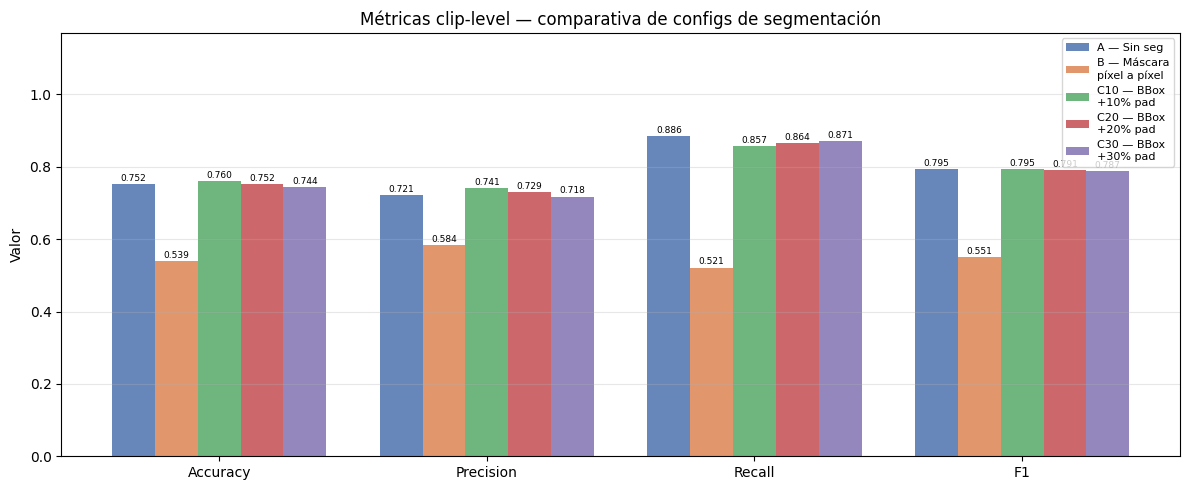

  Guardado: /content/drive/MyDrive/TFM/experiments/video_tests/GAR/runs/seg_ablation/C1_metricas_globales.png


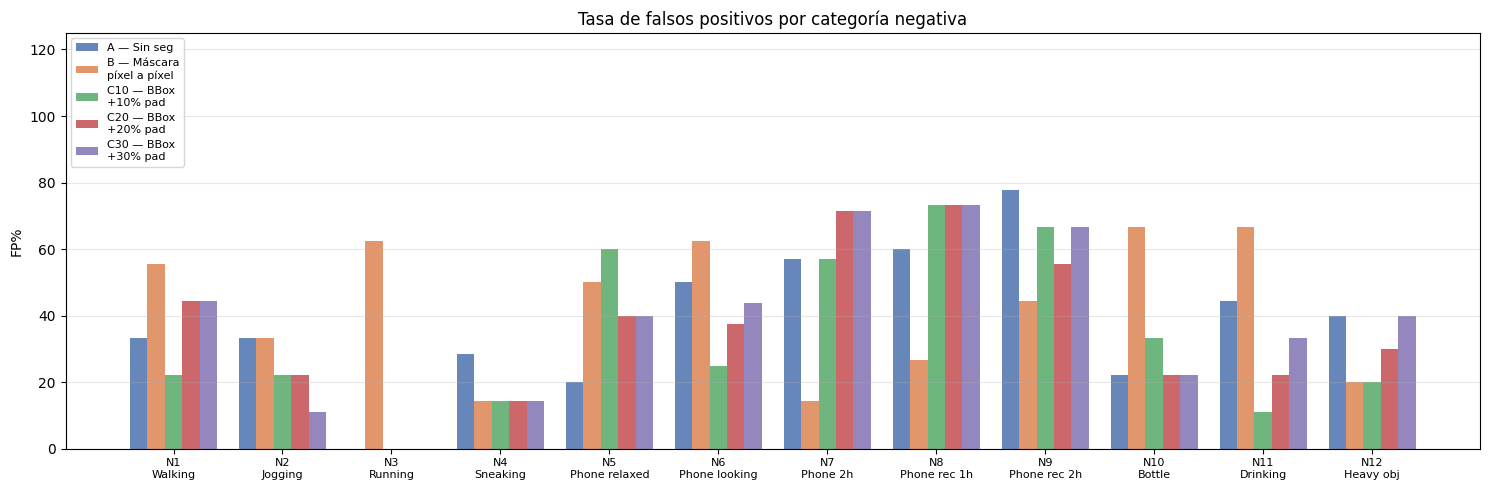

  Guardado: /content/drive/MyDrive/TFM/experiments/video_tests/GAR/runs/seg_ablation/C2_fp_por_categoria.png


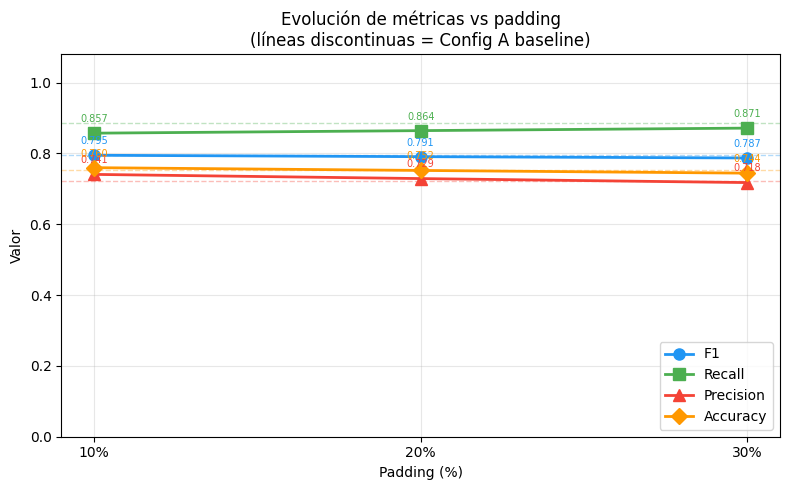

  Guardado: /content/drive/MyDrive/TFM/experiments/video_tests/GAR/runs/seg_ablation/C3_evolucion_padding.png


In [8]:
# ============================================================
# BLOQUE C — Gráficas
# ============================================================
print('\n' + '='*72)
print('BLOQUE C — Gráficas comparativas')
print('='*72)

n_cfgs = len(available)
w      = 0.8 / n_cfgs

# ---- C1: Barras métricas globales clip-level ----
metric_keys = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metric_keys))

fig, ax = plt.subplots(figsize=(12, 5))
for i, cfg in enumerate(available):
    vals   = [metrics[cfg].get(k, 0) for k in metric_keys]
    offset = (i - n_cfgs / 2 + 0.5) * w
    bars   = ax.bar(x + offset, vals, w,
                    label=CFG_LABELS[cfg], color=CFG_COLORS[cfg], alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=6.5)

ax.set_xticks(x)
ax.set_xticklabels(metric_keys)
ax.set_ylim(0, 1.17)
ax.set_ylabel('Valor')
ax.set_title('Métricas clip-level — comparativa de configs de segmentación')
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
path = Path(OUT_DIR) / 'C1_metricas_globales.png'
plt.savefig(str(path), dpi=150, bbox_inches='tight')
plt.show()
print(f'  Guardado: {path}')

# ---- C2: FP% por categoría ----
x = np.arange(len(cats_sorted))
fig, ax = plt.subplots(figsize=(15, 5))
for i, cfg in enumerate(available):
    fp_pcts = []
    for cat in cats_sorted:
        s   = cat_fp[cat][cfg]
        tot = s['total']
        fp_pcts.append(s['fp'] / tot * 100 if tot > 0 else 0)
    offset = (i - n_cfgs / 2 + 0.5) * w
    ax.bar(x + offset, fp_pcts, w, label=CFG_LABELS[cfg],
           color=CFG_COLORS[cfg], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'{c}\n{cat_labels.get(c,"")}' for c in cats_sorted], fontsize=8)
ax.set_ylabel('FP%')
ax.set_ylim(0, 125)
ax.set_title('Tasa de falsos positivos por categoría negativa')
ax.legend(loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
path = Path(OUT_DIR) / 'C2_fp_por_categoria.png'
plt.savefig(str(path), dpi=150, bbox_inches='tight')
plt.show()
print(f'  Guardado: {path}')

# ---- C3: Evolución de métricas vs padding ----
padding_cfgs = [c for c in available if c.startswith('C')]
if padding_cfgs:
    pad_values = [int(c[1:]) for c in padding_cfgs]
    fig, ax = plt.subplots(figsize=(8, 5))

    for metric_key, color, marker in [
        ('F1',        '#2196F3', 'o'),
        ('Recall',    '#4CAF50', 's'),
        ('Precision', '#F44336', '^'),
        ('Accuracy',  '#FF9800', 'D'),
    ]:
        vals = [metrics[c].get(metric_key, 0) for c in padding_cfgs]
        ax.plot(pad_values, vals, color=color, marker=marker,
                linewidth=2, markersize=8, label=metric_key)
        for x_val, y_val in zip(pad_values, vals):
            ax.annotate(f'{y_val:.3f}', (x_val, y_val),
                        textcoords='offset points', xytext=(0, 8),
                        ha='center', fontsize=7, color=color)
        # Línea de referencia Config A
        if 'A' in available:
            ref = metrics['A'].get(metric_key, 0)
            ax.axhline(ref, color=color, linestyle='--', alpha=0.35, linewidth=1)

    ax.set_xlabel('Padding (%)')
    ax.set_ylabel('Valor')
    ax.set_xticks(pad_values)
    ax.set_xticklabels([f'{p}%' for p in pad_values])
    ax.set_ylim(0, 1.08)
    ax.set_title('Evolución de métricas vs padding\n(líneas discontinuas = Config A baseline)')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    path = Path(OUT_DIR) / 'C3_evolucion_padding.png'
    plt.savefig(str(path), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Guardado: {path}')

In [9]:
# ============================================================
# BLOQUE D — Transiciones respecto a Config A
# ============================================================
print('\n' + '='*72)
print('BLOQUE D — Transiciones respecto a Config A (baseline)')
print('='*72)

if 'A' not in available:
    print('  ⚠️  Config A no disponible.')
else:
    df_a = dfs['A']
    compare_cfgs = [c for c in available if c != 'A']

    def transition_label(true, pred_a, pred_b):
        if true == 0 and pred_a == 1 and pred_b == 0: return 'FP→TN ✅'
        if true == 0 and pred_a == 0 and pred_b == 1: return 'TN→FP ❌'
        if true == 1 and pred_a == 1 and pred_b == 0: return 'TP→FN ❌'
        if true == 1 and pred_a == 0 and pred_b == 1: return 'FN→TP ✅'
        return None

    transition_types = ['FP→TN ✅', 'TN→FP ❌', 'TP→FN ❌', 'FN→TP ✅']

    # Tabla resumen de conteos
    counts = {cfg: defaultdict(int) for cfg in compare_cfgs}
    merged_all = {}
    for cfg in compare_cfgs:
        m = df_a[['clip','true','category','pred','det_frames']].merge(
            dfs[cfg][['clip','pred','det_frames']],
            on='clip', suffixes=('_A','_cfg')
        )
        m['transition'] = m.apply(
            lambda r: transition_label(r['true'], r['pred_A'], r['pred_cfg']), axis=1
        )
        merged_all[cfg] = m
        for t in m['transition'].dropna():
            counts[cfg][t] += 1

    print(f'\n  {"Transición":15}  ' + '  '.join(f'{c:>6}' for c in compare_cfgs))
    print('  ' + '-' * (15 + 9 * len(compare_cfgs)))
    for t in transition_types:
        row = f'  {t:15}  ' + '  '.join(f'{counts[cfg][t]:>6}' for cfg in compare_cfgs)
        print(row)

    # Detalle de la mejor config (mayor F1)
    best_cfg = max(compare_cfgs, key=lambda c: metrics[c].get('F1', 0))
    print(f'\n  Detalle completo para la mejor config: {best_cfg} (F1={metrics[best_cfg].get("F1",0):.4f})')

    changed = merged_all[best_cfg][merged_all[best_cfg]['transition'].notna()]
    for t in transition_types:
        subset = changed[changed['transition'] == t]
        if subset.empty:
            continue
        print(f'\n  --- {t} ({len(subset)} clips) ---')
        print(f'  {"Clip":<42} {"Cat":<6} {"det_A":>6} {"det_cfg":>8}')
        for _, row in subset.iterrows():
            print(f'  {row["clip"]:<42} {row["category"]:<6}'
                  f' {int(row["det_frames_A"]):>6} {int(row["det_frames_cfg"]):>8}')


BLOQUE D — Transiciones respecto a Config A (baseline)

  Transición            B     C10     C20     C30
  ---------------------------------------------------
  FP→TN ✅              32      17      13      10
  TN→FP ❌              36      11      10      10
  TP→FN ❌              58       6       5       5
  FN→TP ✅               7       2       2       3

  Detalle completo para la mejor config: C10 (F1=0.7947)

  --- FP→TN ✅ (17 clips) ---
  Clip                                       Cat     det_A  det_cfg
  N11_C1_P2_V1_HB_2                          N11         8        3
  N11_C2_P3_V2_HB_2                          N11        12        4
  N11_C2_P5_V3_HB_1                          N11        12        4
  N12_C2_P5_V1_HB_1                          N12        10        0
  N12_C2_P5_V3_HB_1                          N12        12        2
  N1_C1_P1_V1_HB_1                           N1         12        4
  N1_C2_P3_V2_HB_1                           N1          7        0
  N2_C2